**Question 1: What is Boosting in Machine Learning? Explain how it improves weak
learners.**

**Answer:** Boosting is a sequential ensemble learning technique that converts a collection of weak learners—models that perform only slightly better than random guessing—into a single highly accurate strong learner.

**Boosting improves weak Learners through following methodologies:**

1. Sequential Error Correction: Base models (typically shallow decision trees called decision stumps) are trained step-by-step rather than independently. Each new weak learner is built explicitly to fix the specific errors made by the existing ensemble.

2. Instance Re-Weighting (e.g., AdaBoost): Observations misclassified by prior iterations are assigned higher weights, forcing the next weak learner to focus primarily on hard-to-predict data points.

3. Residual Fitting (e.g., Gradient Boosting): Instead of modifying sample weights, each subsequent weak learner is fitted directly to the residual errors (the difference between actual targets and current model predictions) of the combined ensemble.

4. Weighted Aggregation: Predictions are combined via a weighted vote or sum, where stronger individual models are assigned greater weight ($\alpha$) in the final decision than weaker ones.

5. Progressive Bias Reduction: While an individual weak learner suffers from high bias, repeatedly adding targeted models iteratively eliminates systematic errors, drastically lowering overall bias while keeping variance under control.

**Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

**Answer:** AdaBoost and Gradient Boosting both train models sequentially to improve weak learners, but they use fundamentally different mechanisms to track errors and update base models during training.

**1. Error Tracking Mechanism**

**AdaBoost**: Uses sample weights. Instances misclassified in a given iteration receive higher weights so subsequent weak learners focus on hard-to-predict samples.

**Gradient Boosting**: Uses loss function residuals (gradients). Subsequent weak learners are fitted directly to the pseudo-residuals (negative gradients) calculated from current predictions.

**2. Loss Function Flexibility**

**AdaBoost**: Restricted primarily to exponential loss (or surrogate classification losses).

**Gradient Boosting:** Flexible with any differentiable loss function (such as Mean Squared Error, Log-Loss, Huber Loss, or custom business metrics).

**3. Model Optimization Strategy**

**AdaBoost:** Optimizes iteratively by adjusting instance weights based on classification errors from the previous model.

**Gradient Boosting:** Applies gradient descent in function space to iteratively minimize the loss function.

**4. Combining Base Model Outputs**

**AdaBoost:** Assigns a unique performance weight ($\alpha$) to each base learner based on its accuracy; stronger models carry greater influence in the final prediction.

**Gradient Boosting:** Multiplies all base tree predictions by a fixed global learning rate ($\eta$) and adds them to the ensemble's running total.

**5. Sensitivity to Outliers and Noise**

**AdaBoost:** Highly sensitive to outliers because misclassified noise repeatedly receives escalating weights in subsequent iterations.

**Gradient Boosting:** More resistant to outliers, especially when configured with robust loss functions (such as Huber or MAE loss).

**Question 3: How does regularization help in XGBoost?**

**Answer:** In XGBoost, regularization is built directly into the objective function to control model complexity and prevent overfitting. Unlike traditional Gradient Boosting, which primarily relies on tree depth limits and learning rates, XGBoost optimizes a regularized objective function at every step:$$\text{Objective}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$where $l$ is the loss function measuring prediction error, and $\Omega(f_t)$ is the regularization term for tree $f_t$:$$\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2 + \alpha \sum_{j=1}^{T} \vert{}w_j\vert{}$$

**Components of XGBoost Regularization**

1. Tree Complexity Penalty ($\gamma$ / gamma)

Mechanism: Penalizes the total number of leaves ($T$) in a tree.

Effect: Acts as a threshold for node splitting. A node is split only if the gain from the split exceeds $\gamma$. If the gain is smaller than $\gamma$, the split is pruned, preventing trees from growing unnecessarily deep.

2. $L_2$ Regularization ($\lambda$ / reg_lambda)

Mechanism: Penalizes the squared sum of leaf weights ($\sum w_j^2$).

Effect: Shrinks leaf weights toward zero, smoothing predictions and making the model less sensitive to individual extreme data points. It also adds stability when calculating split scores, preventing divisions by near-zero Hessians.

3. $L_1$ Regularization ($\alpha$ / reg_alpha)

Mechanism: Penalizes the absolute sum of leaf weights ($\sum \vert{}w_j\vert{}$).

Effect: Forces uninformative leaf weights exactly to zero, producing sparse models. This performs implicit feature selection and helps handle high-dimensional or sparse datasets.Primary

**Benefits of Regularization in XGBoost**

> Prevents Overfitting: By penalizing deep trees and large leaf weights, it stops weak learners from memorizing noise in the training set.Stabilizes Learning on

> Small or Noisy Data: Prevents individual outliers from exerting disproportionate influence on predictions.Improves Generalization: Smooths decision boundaries, ensuring better performance on unseen test data.

> Automates Pruning: The interaction between loss gain and $\gamma$ naturally prunes non-beneficial branches during construction.

**Question 4: Why is CatBoost considered efficient for handling categorical data**
**Answer:** CatBoost (Categorical Boosting) is specifically designed to handle categorical data efficiently because it solves the critical issue of target leakage (data leakage) present in traditional target encoding techniques, while handling high-cardinality categories automatically without requiring manual preprocessing.

1. Ordered Target Statistics (Preventing Target Leakage)

CatBoost uses Ordered Target Encoding: it calculates target statistics sequentially based on random permutations of the training dataset.

2. On-the-Fly Feature Combinations

CatBoost constructs combinations of categorical features (and categorical-numerical features) dynamically on-the-fly during tree node splits. Instead of computing combinations for all possible feature pairs upfront (which leads to exponential memory overhead), CatBoost evaluates combinations only for features present in the current branch.

3. Dual Handling based on Feature Cardinality

CatBoost automatically applies the optimal encoding strategy based on category cardinality.

4. Elimination of Preprocessing Pipelines

CatBoost accepts raw categorical strings or integers directly as input without requiring manual One-Hot Encoding, Label Encoding, or Target Encoding pipelines, reducing code complexity and deployment risk.

**Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?**

**Answer:** Boosting is preferred over bagging in real-world applications with structured, tabular data where subtle non-linear interactions dictate outcomes, predictive precision is paramount, and minimizing model bias takes priority over simple variance reduction.

Examples mentioned below are the ones I have come across in my professional experience

**Fraud and Anomaly Detection**

  Context: Detecting credit card fraud, insurance claim manipulation, or unauthorized network access.

  Why Boosting: Fraud cases exhibit extreme class imbalance and evolving patterns. Boosting’s instance re-weighting and residual fitting force base models to concentrate on rare, difficult-to-detect fraudulent transactions rather than defaulting to the majority non-fraud class.

**Dynamic Pricing and Demand Forecasting**

  Context: Ride-hailing platforms and e-commerce companies dynamically adjusting prices based on real-time supply, demand, and weather.

  Why Boosting: Demand sensitivity requires modeling multi-variable non-linear dynamics with low bias. Boosting minimizes systematic error margins, enabling precise revenue and volume predictions.

Datasets:
● Use
```
sklearn.datasets.load_breast_cancer()
```
for classification tasks.


● Use
```
sklearn.datasets.fetch_california_housing()
```
for regression tasks.



In [1]:
'''
Question 6: Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy
'''
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# 1. Load Breast Cancer dataset
dataset = load_breast_cancer()
X, y = dataset.data, dataset.target

# 2. Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train AdaBoost Classifier
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 5. Output results
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=dataset.target_names))


Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [2]:
'''
Question 7: Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score
'''
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 1. Load California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train, y_train)

# 4. Predict on test set and evaluate R-squared score
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)

# 5. Output R-squared score
print(f"Gradient Boosting Regressor R2 Score: {r2:.4f}")

Gradient Boosting Regressor R2 Score: 0.7756


In [3]:
'''
Question 8: Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy
'''
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

# 1. Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Define grid for learning_rate tuning
param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]}

# 4. Instantiate XGBoost Classifier and setup GridSearchCV
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(
    estimator=xgb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

# 5. Fit grid search on training data
grid_search.fit(X_train, y_train)

# 6. Evaluate the best model on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 7. Print best parameter and final accuracy
print("Best Parameters:", grid_search.best_params_)
print(f"Final Test Accuracy : {accuracy:.4f}")

Best Parameters: {'learning_rate': 0.3}
Final Test Accuracy : 0.9561


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


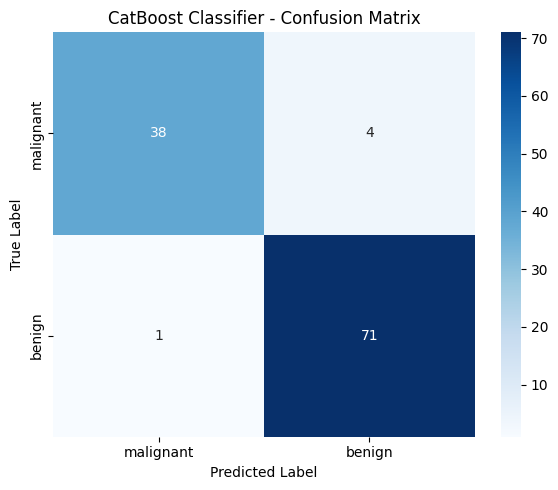

In [5]:
'''
Question 9: Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn
'''
!pip install catboost -q
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train CatBoost Classifier
# verbose=0 suppresses step-by-step training log output
model = CatBoostClassifier(verbose=0, random_state=42)
model.fit(X_train, y_train)

# 4. Generate predictions and compute confusion matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 5. Plot confusion matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names,
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CatBoost Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

**Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior.**

**The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.**

**Describe your step-by-step data science pipeline using boosting techniques:**

**● Data preprocessing & handling missing/categorical values**

**● Choice between AdaBoost, XGBoost, or CatBoost**

**● Hyperparameter tuning strategy**

**● Evaluation metrics you'd choose and why**

**● How the business would benefit from your mode**


**Answer:**

**1. Data Preprocessing & Handling Missing/Categorical Values**

1. Handling Missing Values:Standard statistical imputation (mean/median) is avoided because missingness in transaction logs often carries predictive signal (e.g., thin-file applicants). Features are processed using algorithm-native missing value split routing, while transactional counts are explicitly imputed with $0$ and missing categorical entries with an "Unknown" token.

2. Categorical Feature Processing: High-cardinality features (merchant category codes, zip codes, employment categories) are preserved in raw format without One-Hot Encoding to avoid excessive matrix sparsity and memory explosion.

3. Addressing Class Imbalance: Imbalance (typically $2\text{--}5\%$ default rate) is handled via cost-sensitive objective weighting (auto_class_weights='Balanced' or scale_pos_weight) during loss computation rather than synthetic oversampling (SMOTE), preserving authentic transactional distributions.

**2. Model Choice: CatBoost**

    Selected Framework: CatBoost (with XGBoost as a baseline).

1. Ordered Target Statistics: Encodes categorical features on-the-fly without target leakage or overfitting.

2. Outlier Resilience: Financial transaction logs often contain extreme spending outliers; CatBoost's symmetric tree structures stabilize predictions against noisy inputs.

3. Native Handling of Missing Data: Learns optimal split paths for missing values during tree construction.

**3. Hyperparameter Tuning Strategy**

> Validation Scheme: Implement 5-Fold Stratified Cross-Validation coupled with an Out-of-Time (OOT) test set (e.g., past 3 months of loans) to evaluate temporal drift.

Tuning Tool: Use Optuna for Bayesian optimization over a structured parameter space:

> Tree Depth (depth): Bound between $4\text{--}8$ to keep base learners shallow and prevent memorizing individual user histories.

> $L_2$ Regularization (l2_leaf_reg): Search between $1\text{--}10$ to shrink leaf weights and smooth risk estimates.

> Subsampling (subsample): Set between $0.7\text{--}0.9$ to inject row-level randomness per tree.
> Learning Rate (learning_rate): Set low ($0.02\text{--}0.05$) combined with early stopping (early_stopping_rounds=50) on validation loss.

**4. Evaluation Metrics & Reason**

> Primary Metric — PR-AUC (Precision-Recall AUC): In severely imbalanced settings, ROC-AUC can present an overly optimistic view due to a large True Negative count. PR-AUC measures the trade-off between capturing defaulters (Recall) and minimizing false alarms (Precision).

> Threshold-Based Metric — Recall at $80\%$ Precision: Evaluates how many actual defaulters the model catches when maintaining an acceptable application rejection accuracy.

Business Metric — Expected Monetary Loss Matrix:

> False Negative Cost: Loss of unpaid principal ($\approx \$10,000$ per defaulted loan).

> False Positive Cost: Lost revenue interest ($\approx \$500$ in foregone profit).

> The optimal decision threshold is chosen where total net portfolio cost is minimized.

**Business benefits of my Model:**

> Capital Protection: Reduces non-performing loan (NPL) rates by accurately identifying high-risk applicants before credit extension.

> Underwriting Speed: Replaces slow manual review processes with automated, instant credit decisions.

> Regulatory Explainability: Combines CatBoost with SHAP (SHapley Additive exPlanations) values to auto-generate compliant, legally mandated reason codes (e.g., Adverse Action notices) explaining loan rejections.